## 教程五：SSQITE 算法求解多能级（基态与激发态）

在之前的教程中，我们学习了如何利用 变分量子虚时演化（VarQITE） 和 随机测量加速的虚时演化（RMITE） 来寻找量子系统的基态。然而，许多物理和化学问题不仅要求基态，还需要获得低能激发态的信息（例如吸收光谱、反应路径等）。如果每次只计算一个能级，需要反复施加正交约束并独立运行算法，计算成本高且容易陷入局域态。  
子空间搜索量子虚时演化（Subspace‑Search Quantum Imaginary Time Evolution, SSQITE） 提供了一种优雅的解决方案：它在一个共享的参数化电路框架中同时演化多个正交态，通过指数衰减的时间步长和自适应权重，使各个态分别收敛到不同的低能本征态。本节我们将从算法原理出发，详细推导 SSQITE 的数学基础，并通过两比特 Ising 模型的数值模拟展示其求解基态和激发态的能力。

### 1. SSQITE 算法原理：从单一态到多态并行演化
#### 1.1 回顾：单态的虚时间演化
对于单个态 $|\psi(\tau)\rangle$ ，虚时间演化由 Wick‑薛定谔方程描述：
$$ \frac{\partial|\psi(\tau)\rangle}{\partial\tau}=-\left(H-E(\tau)\right)|\psi(\tau)\rangle,\quad E(\tau)=\frac{\langle\psi(\tau)|H|\psi(\tau)\rangle}{\langle\psi(\tau)|\psi(\tau)\rangle}$$
当以参数化量子电路 $|\phi(\theta)\rangle$ 逼近真实演化态时，变分原理给出参数运动方程：
$$ \mathcal{F}_{Q}(\boldsymbol{\theta})\dot{\boldsymbol{\theta}}=-2\nabla_{\boldsymbol{\theta}}E(\boldsymbol{\theta})$$
其中 $ \mathcal{F}_{Q}$ 是量子 Fisher 信息矩阵（QFIM）。对于多个态，我们需要保证它们彼此正交，并且各自向不同的本征态收敛。

#### 1.2 SSVQE 简介
核心思想：在量子力学中，不同的本征态（如基态和激发态）是相互正交的。正交性保护传统的 VQE 通常只关注基态。如果我们想要激发态，必须保证激发态与基态正交。SSVQE 利用了量子电路 $U(\theta)$ 的幺正性。幺正变换不改变向量间的内积。  
输入： 我们选取一组简单且相互正交的计算基态 $|\phi_j\rangle$，例如 $\{|00\rangle, |01\rangle\}$。  
过程： 它们通过同一个参数化电路 $U(\theta)$，变为  $|\psi_j(\theta)\rangle$。因为 $\langle \phi_i(\theta) | \phi_j(\theta)\rangle$，且 $U$ 是幺正的，所以输出态必然正交：$\langle \psi_i(\theta) | \psi_j(\theta)\rangle$。  
目标函数： 最小化加权能量和 $L(\theta) = \sum w_j \langle \psi_j(\theta) | H | \psi_j(\theta) \rangle$。  

局限性： SSVQE 依赖经典的梯度下降优化器（如 Adam, COBYLA）。在复杂的参数空间中，极易陷入局部极小值或遭遇贫瘠高原，导致优化停滞，无法找到真正的基态和激发态。

#### 1.3 算法原理与核心机制 

SSQITE的初始化需要准备 $k$ 个正交的初始态 $|\phi_j\rangle$，在演化部分采用和VarQITE相似的虚时演化思路，即求解由 McLachlan变分原理 推导得出的线性方程组 $\mathcal{A} \cdot \dot{\vec{\theta}} = \mathcal{C}$，从而更新参数。而SSQITE相比传统方法的创新点在于以下两点：
1.   **加权McLachlan变分原理 (Weighted McLachlan's Principle)**  
SSQITE 试图寻找一组变分参数 $\vec{\theta}(\tau)$，使得参数化电路 $U(\vec{\theta})$ 作用在正交输入态 $|\phi_j\rangle$ 上产生的态 $|\psi_j(\vec{\theta})\rangle$，能近似遵循虚时演化方程：$$\frac{d}{d\tau}|\psi_j\rangle = -(H - \langle H \rangle_j)|\psi_j\rangle$$为了在同一个参数化电路中同时处理多个态，并保证它们分别收敛到第 $0, 1, ..., k$ 个激发态，SSQITE 采用了加权McLachlan变分原理  $\dot{\theta}$，而是寻找一个 $\dot{\theta}$，使得整个子空间内的所有态的总演化误差最小：
$$\delta \sum_{j \in S} d\tau_j \left\| \left( \frac{\partial}{\partial \tau} + (H - E_j) \right) |\psi_j(\vec{\theta})\rangle \right\|^2 = 0$$这导出了一个新的线性方程组，其系数矩阵是所有态贡献的加权叠加:$\dot{\vec{\theta}}$ 通过求解以下线性方程组获得：$$\mathcal{A} \cdot \dot{\vec{\theta}} = \mathcal{C}$$其中，
$$\mathcal{A}_{mn} = \sum_{j=0}^{k-1} d\tau_j \cdot \text{Re}\left( \frac{\partial \langle \psi_j |}{\partial \theta_m} \frac{\partial | \psi_j \rangle}{\partial \theta_n} \right)$$
$$\mathcal{C}_{m} = -\sum_{j=0}^{k-1} d\tau_j \cdot \text{Re}\left( \sum_{r} c_r \langle \frac{\partial \psi_j}{\partial \theta_m} | H_r | \psi_j \rangle \right)$$

2. **变时间步长机制**  
如果所有态的权重/步长相同，由于虚时演化的特性，所有态 $|00\rangle, |01\rangle \dots$ 都会试图收敛到基态，导致参数更新方向冲突或数值不稳定。为了分离出不同的能级，算法人为引入了演化速率的差异。简单地说就是：让低能态跑得快，先占据基态；高能态跑得慢，依次向上占据激发态。  
论文提出，第 $j$ 个激发态的演化时间步长 $d\tau_j$ 设为：$$d\tau_j = \frac{b}{2^j}$$基态 ($j=0$)：最先“抢占”基态的位置。第一激发态 ($j=1$)：步长减半，当它想往基态跑时，发现参数空间已经被基态占据（受正交性限制），它只能被迫收敛到能量次低的位置（即第一激发态）。以此类推。  
从数学角度解释，基态优先 ($j=0$)意味着它拥有最大的权重 ($w=1$)。在解线性方程时，它的 $A_0$ 和 $C_0$ 占主导地位。参数 $\vec{\theta}$ 主要沿着基态需要的方向更新，迅速锁定基态子空间。当基态已经被占据后，剩下的态中第一激发态 ($j=1$)的 $A_1$ 和 $C_1$ 占据主导位置，以此类推。  
论文还利用几何级数的性质，阐述了：基态的权重大于所有激发态权重之和，从而证明低能态不会被高能态带偏，此“权重因子”能够保证基态在演化中的主导地位。
$$\frac{1}{2^i} > \sum_{j=i+1}^{k} \frac{1}{2^j}$$

### 2. 代码示例

为了验证 SSQITE 的效果，我们选用一个简单但具有明确解析解的两比特 Ising 模型。其哈密顿量为：
$$H=0.5I\otimes I-1.5Z\otimes I-1.0I\otimes Z$$
其本征值为：  
基态： $E_0=-2.0$  
第一激发态：$E_1=0.0$  
第二激发态：$E_2=1.0$  

#### 2.1 导入必要的库

In [5]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  # 如果 notebook 在 examples/ 下
sys.path.insert(0, PROJECT_ROOT)

In [ ]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from hyq.backends.Tensorcircuit import TensorCircuitBackend
from hyq.backends.core import QuantumCircuit
from hyq.solvers import SSQITESolver

#### 2.2 定义参数量子电路（Ansatz）

In [7]:
def notebook_ansatz(params):
    n_qubits = 2
    n_layers = 3
    qc = QuantumCircuit(n_qubits)
    if not isinstance(params, torch.Tensor): 
        params = torch.tensor(params)
    
    idx = 0
    # 初始旋转层
    for i in range(n_qubits):
        qc.ry(i, params[idx]); idx+=1
        qc.rz(i, params[idx]); idx+=1
    
    # 纠缠 + 旋转层
    for _ in range(n_layers):
        if n_qubits > 1: qc.cx(0, 1)
        for i in range(n_qubits):
            qc.ry(i, params[idx]); idx+=1
            qc.rz(i, params[idx]); idx+=1
    return qc

#### 2.3 定义物理模型与运行 SSQITE

In [8]:
# Ising 模型哈密顿量（以 Pauli 字符串形式给出）
hamiltonian = [(0.5, 'II'), (-1.5, 'ZI'), (-1.0, 'IZ')]
n_states = 3  # 求解前 3 个最低能级（基态 + 2 个激发态）

backend = TensorCircuitBackend()
solver = SSQITESolver(backend)

# 随机初始化参数（范围 [0, 2π)）
init_params = torch.rand(16) * 2 * np.pi   # 16 个参数 = 2*2*(3+1)

print(f"--- SSQITE 开始: 求解 {n_states} 个能级 ---")

final_energies, final_params, history = solver.solve(
    ansatz_func=notebook_ansatz,
    init_params=init_params,
    hamiltonian=hamiltonian,
    n_states=n_states,
    b_step=0.05,      # 初始步长
    max_steps=100     # 总迭代步数（内部按阶段递减步长）
)

--- SSQITE 开始: 求解 3 个能级 ---
--- SSQITE Start: States=3, b=0.05, Steps=100 ---
--- Weights (Time Steps): [0.05, 0.025, 0.0125] ---
Step 0   | Energies: [1.3073, 1.1178, -0.1836] (0.158s)
Step 10  | Energies: [-1.1370, 0.2606, 1.1748] (0.147s)
Step 20  | Energies: [-1.6101, -0.1709, 1.2089] (0.137s)
Step 30  | Energies: [-1.8404, -0.1051, 1.1334] (0.145s)
Step 40  | Energies: [-1.9405, -0.0432, 1.0821] (0.147s)
Step 50  | Energies: [-1.9784, -0.0157, 1.0503] (0.140s)
Step 60  | Energies: [-1.9921, -0.0055, 1.0312] (0.142s)
Step 70  | Energies: [-1.9969, -0.0019, 1.0195] (0.141s)
Step 80  | Energies: [-1.9987, -0.0008, 1.0124] (0.137s)
Step 90  | Energies: [-1.9993, -0.0004, 1.0080] (0.145s)
Step 99  | Energies: [-1.9996, -0.0003, 1.0054] (0.159s)


在 SSQITESolver 内部，max_steps 会被自动分成若干个阶段，每个阶段的步长按 $\frac{b}{2^j}$ 递减。每步更新时，求解器会按照当前能量从低到高的顺序依次计算各态的 QFIM 和梯度，然后执行欧拉更新。

#### 2.4 多能级收敛曲线可视化

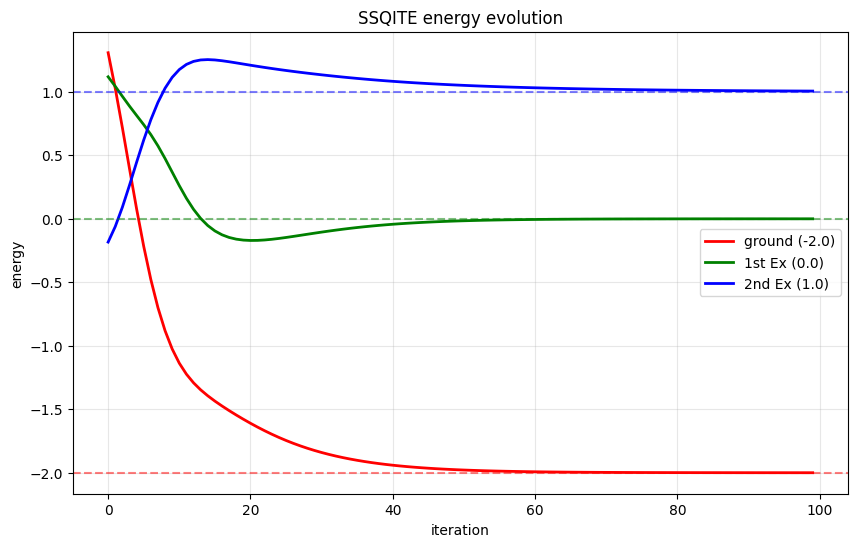

最终能量: [-1.999579954211184, -0.00032834186475438367, 1.0054387556488076]


In [13]:
history = np.array(history)  # 形状 (steps, n_states)
plt.figure(figsize=(10, 6))

labels = ['ground (-2.0)', '1st Ex (0.0)', '2nd Ex (1.0)']
colors = ['red', 'green', 'blue']

for i in range(n_states):
    plt.plot(history[:, i], label=labels[i], color=colors[i], linewidth=2)

# 绘制理论参考线
plt.axhline(y=-2.0, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=0.0, color='green', linestyle='--', alpha=0.5)
plt.axhline(y=1.0, color='blue', linestyle='--', alpha=0.5)

plt.title("SSQITE energy evolution")
plt.xlabel("iteration")
plt.ylabel("energy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("最终能量:", final_energies)

**结果如预期所示**：三条曲线分别趋向 -2.0、0.0、1.0。由于初始参数随机，早期能量可能不规则，但随演化进行，基态首先下降；激发态可能先漂移后稳定在目标值附近。

### 3. 总结
本教程介绍了 子空间搜索量子虚时演化（SSQITE） 的核心思想：通过多态并行演化、指数衰减的时间步长以及可选的惩罚项，在单个算法运行中同时求解一个量子系统的基态和多个激发态。我们以两比特 Ising 模型为例，实现了 Ry‑Rz 硬件高效拟设，并演示了 SSQITE 如何成功收敛到前三低能级。  
SSQITE 为量子化学、凝聚态物理等需要多能级信息的领域提供了一种计算高效的解决方案。结合先前的 RMITE 技术，未来可以在较大规模系统中以近线性的每步开销跟踪多个能级。感兴趣的读者可以尝试修改 **b_step、max_steps** 等超参数，观察收敛速度和精度的变化。

### 4. 参考文献
[1] Cianci, C., Santos, L.F., & Batista, V.S. (2024). Subspace-Search Quantum Imaginary Time Evolution for Excited State Computations. Journal of chemical theory and computation.